ex: trains cabins coaches:

A2, etc:

A indicates class, 2 indicates coach number
conver to :
class|coach number table


other type:

col: 1 2 3  a d s

cnverted:

num: 1  2   3 na na na
cat: na na na a d s

In [81]:
import pandas as pd
import numpy as np

In [82]:
df = pd.read_csv("../Data sets/titanicMixed.csv")

In [83]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


### problem: number has number of members someone is traveling with and for 0 its indicated as "A" - Alone

In [84]:
df['number'].unique()

<ArrowStringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

Text(0.5, 1.0, 'No of people a passesnger is traveling with')

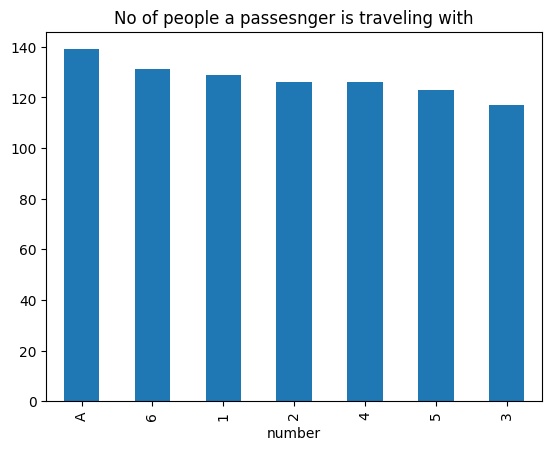

In [85]:
fig = df['number'].value_counts().plot.bar()
fig.set_title('No of people a passesnger is traveling with')

In [86]:
fig

<Axes: title={'center': 'No of people a passesnger is traveling with'}, xlabel='number'>

# 1. Extract numerical part

`syntax`
````python
pd.to_numeric(arg, errors='raise'|'ignore'|'coerce', downcast=None|'integer'|'signed'|'unsigned'|'float')

In [87]:
df['number_numeric'] = pd.to_numeric(df['number'],errors='coerce',downcast='integer')

Setting errors='coerce' forces Pandas to ignore the error and transform any non-numeric text character directly into NaN (Not a Number).

downcast='integer'
By default, standard missing values (NaN) in Pandas turn integers into floating-point numbers (e.g., 5.0). The downcast='integer' parameter aims to optimize memory performance and pull the data types down to the smallest possible integer format where valid integers exist.

`syntax`

````python
np.where(condition, value_if_true, value_if_false)

In [88]:
df['number_categorical'] = np.where(df['number_numeric'].isnull(),df['number'],np.nan)

In [89]:
df.head()

,Cabin,Ticket,number,Survived,number_numeric,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [90]:
df['Cabin'].unique()

<ArrowStringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [91]:
df['Ticket'].unique()

<ArrowStringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str

Cabin and Ticket are different from number as they have too many unique values and they have mixed(cat+num) values

In [92]:
df['Cabin_num'] = df['Cabin'].str.extract('(\d+)') #capture numeric
df['Cabin_cat'] = df['Cabin'].str[0] #capture 1st str

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\luqma\AppData\Local\Temp\ipykernel_23816\3715435369.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Cabin_num'] = df['Cabin'].str.extract('(\d+)') #capture numeric


In [93]:
df.head()

,Cabin,Ticket,number,Survived,number_numeric,number_categorical,Cabin_num,Cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


In [94]:
df['Cabin_cat'].value_counts()

Cabin_cat
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

### for ticket

In [97]:
df['ticket_num'] = df['Ticket'].str.extract('(\d+)$')
df['ticket_cat'] = df['Ticket'].str.extract(r'(.*)(?=\s\d)')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\luqma\AppData\Local\Temp\ipykernel_23816\3250250338.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['ticket_num'] = df['Ticket'].str.extract('(\d+)$')


In [98]:
df

,Cabin,Ticket,number,Survived,number_numeric,number_categorical,Cabin_num,Cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450,NaN
...,...,...,...,...,...,...,...,...,...,...
886,NaN,211536,3,0,3.0,NaN,NaN,NaN,211536,NaN
887,B42,112053,3,1,3.0,NaN,42,B,112053,NaN
888,NaN,W./C. 6607,1,0,1.0,NaN,NaN,NaN,6607,W./C.
889,C148,111369,2,1,2.0,NaN,148,C,111369,NaN
